# 01 — TBXT SPR Data Preparation

This notebook is the single source of truth for preparing the TBXT SPR binding affinity
dataset for downstream modeling. It loads a pre-merged CSV of 14 experimental batches,
cleans it, and exports modeling-ready tables.

---

## Data provenance

**Source:** HD Biosciences performed surface plasmon resonance (SPR) binding affinity screens
of low-molecular-weight compounds against human TBXT (Brachyury). Raw data were released on
[Zenodo](https://zenodo.org/) as 15 password-protected Excel files spanning October 2020
through January 2023.

**Pre-processing:** A separate merge script combined 14 of the 15 files into
`tbxt_spr_merged.csv`. One file (`20210719`) was excluded because 114 of its compound IDs
lack SMILES in any available lookup source (proprietary Piramal/ChemSpace catalog IDs).

**Compound sources:**

| Prefix | Supplier | Notes |
|--------|----------|-------|
| `CF-*` | Piramal Pharma Solutions ("CF Labs") | Series CF-2 through CF-10 |
| `UNC-*` | UNC Chapel Hill (Drewry lab) | UNC-AH, UNC-ZDG, UNC-HO series |
| `CSC*` | ChemSpace | Catalog compounds |
| `MCULE-*` | MCULE | Virtual screening hits |
| numeric IDs | ChemSpace / other vendors | Catalog numbers without prefix |
| `M567200` | ChemSpace (reference compound) | Positive control across experiments |

**SMILES resolution:** Compound structures were resolved from two lookup files
(`ID_with_SMILES.xlsx` and `Naar_SMILES.xlsx`) plus one manual override for the
reference compound M567200/CSC015274258.

**Key columns in the merged CSV:**

| Column | Description |
|--------|-------------|
| `compound_id` | Cleaned compound name (replicates stripped) |
| `smiles` | SMILES from lookup (null if unresolved) |
| `KD_M` | Equilibrium dissociation constant (molar) |
| `pKD` | -log10(KD_M); higher = more potent |
| `reference_date` | Experiment batch (YYYYMMDD) |

---

## Pipeline summary

1. **Load** raw merged CSV (2,143 records)
2. **Filter** to records with both SMILES and pKD
3. **Remove** ambiguous compound IDs (1 ID mapping to multiple SMILES)
4. **Assign** supplier labels from compound ID prefixes
5. **Average** replicates within each experiment batch
6. **Validate** SMILES with RDKit; canonicalize
7. **Compute** molecular properties; flag Chordoma Foundation filter compliance
8. **QC visuals:** distributions, per-batch, per-supplier breakdowns
9. **Collapse** to one row per unique compound
10. **Export** clean CSVs for modeling

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)

DATA_DIR = Path("../data")
RAW_CSV = DATA_DIR / "zenodo" / "tbxt_spr_merged.csv"
assert RAW_CSV.exists(), f"Missing {RAW_CSV}"

---
## 1. Load raw merged data

In [2]:
raw = pd.read_csv(RAW_CSV)
assert raw.shape[0] > 0, "Empty CSV"

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Total records | {len(raw):,} |
| Unique compound IDs | {raw['compound_id'].nunique():,} |
| Unique SMILES strings | {raw['smiles'].nunique():,} |
| Records with SMILES | {raw['smiles'].notna().sum():,} |
| Records with pKD | {raw['pKD'].notna().sum():,} |
| Records with both | {(raw['smiles'].notna() & raw['pKD'].notna()).sum():,} |
| Experiment batches | {raw['reference_date'].nunique()} |
| Date range | {raw['reference_date'].min()} to {raw['reference_date'].max()} |
"""))


| Metric | Value |
|--------|-------|
| Total records | 2,143 |
| Unique compound IDs | 1,792 |
| Unique SMILES strings | 1,854 |
| Records with SMILES | 2,131 |
| Records with pKD | 1,890 |
| Records with both | 1,880 |
| Experiment batches | 14 |
| Date range | 20200928 to 20230103 |


In [3]:
display(Markdown("### Column null counts"))
null_df = raw.isnull().sum().to_frame("nulls")
null_df["%"] = (100 * null_df["nulls"] / len(raw)).round(1)
null_df[null_df["nulls"] > 0]

### Column null counts

,nulls,%
replicate,1874,87.4
smiles,12,0.6
KD_M,253,11.8
pKD,253,11.8
kd_source_col,253,11.8
ka_1_Ms,1891,88.2
kd_off_1_s,1891,88.2
molecular_weight,474,22.1


---
## 2. Assign supplier labels

Compound IDs follow naming conventions that identify their source.
We assign a `supplier` column for stratified QC.

In [4]:
def assign_supplier(cid: str) -> str:
    if not cid:
        return "Other"
    if cid.startswith("CF-"):
        return "Piramal (CF Labs)"
    elif cid.startswith("UNC-"):
        return "UNC Chapel Hill"
    elif cid.startswith("CSC"):
        return "ChemSpace"
    elif cid.startswith("MCULE"):
        return "MCULE"
    elif cid.startswith("M567200"):
        return "Reference (M567200)"
    elif cid[0].isdigit():
        return "ChemSpace (numeric)"
    else:
        return "Other"


raw["supplier"] = raw["compound_id"].apply(assign_supplier)

supplier_summary = (
    raw.groupby("supplier")
    .agg(
        records=("compound_id", "count"),
        unique_compounds=("compound_id", "nunique"),
        unique_smiles=("smiles", "nunique"),
        has_pKD=("pKD", lambda x: x.notna().sum()),
    )
    .sort_values("records", ascending=False)
)
display(Markdown("### Records by supplier"))
supplier_summary

### Records by supplier

,records,unique_compounds,unique_smiles,has_pKD
supplier,,,,
Piramal (CF Labs),1181,1100,1092,1052
UNC Chapel Hill,329,195,278,268
ChemSpace,263,256,256,242
Other,138,111,110,129
Reference (M567200),100,1,1,100
ChemSpace (numeric),72,72,66,65
MCULE,60,57,52,34


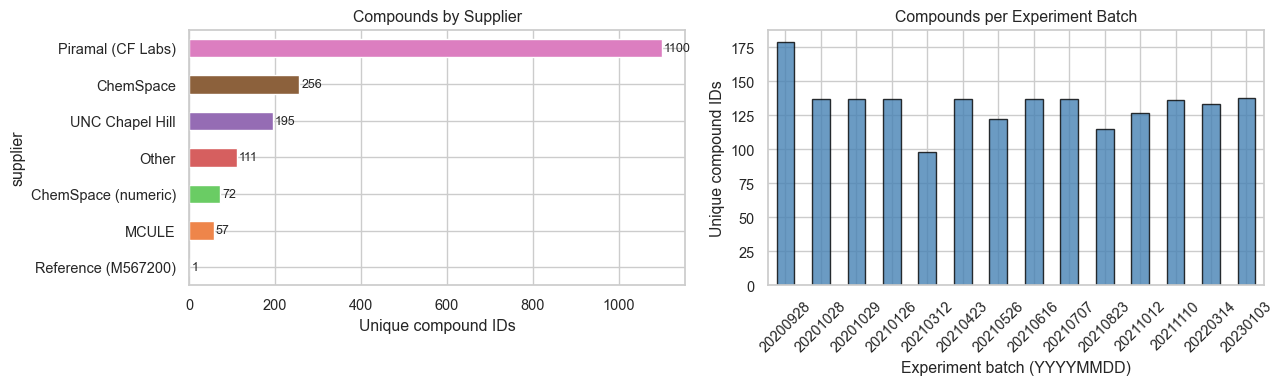

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

supplier_cpd = (
    raw.groupby("supplier")["compound_id"]
    .nunique()
    .sort_values(ascending=True)
)
supplier_cpd.plot.barh(ax=axes[0], color=sns.color_palette("muted", len(supplier_cpd)))
axes[0].set_xlabel("Unique compound IDs")
axes[0].set_title("Compounds by Supplier")
for i, v in enumerate(supplier_cpd.values):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=9)

date_counts = (
    raw.groupby("reference_date")["compound_id"]
    .nunique()
    .sort_index()
)
date_counts.plot.bar(ax=axes[1], color="steelblue", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Experiment batch (YYYYMMDD)")
axes[1].set_ylabel("Unique compound IDs")
axes[1].set_title("Compounds per Experiment Batch")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## 3. Filter to usable records

We need both a resolved SMILES and a measured pKD to use a record for modeling.

In [6]:
n_before = len(raw)
df = raw.dropna(subset=["smiles", "pKD"]).copy()
n_dropped = n_before - len(df)

display(Markdown(f"""
| Step | Records |
|------|---------|
| Starting | {n_before:,} |
| Dropped (missing SMILES or pKD) | {n_dropped:,} |
| **Remaining** | **{len(df):,}** |
"""))
assert len(df) > 0


| Step | Records |
|------|---------|
| Starting | 2,143 |
| Dropped (missing SMILES or pKD) | 263 |
| **Remaining** | **1,880** |


---
## 4. Remove ambiguous compound IDs

Some compound IDs (mostly UNC series-level names like `UNC-ZDG-87`) map to
multiple distinct SMILES. These are genuinely different molecules sharing a
series prefix. We can't determine which structure a measurement corresponds
to, so we exclude them.

In [7]:
smiles_per_id = df.groupby("compound_id")["smiles"].nunique()
ambiguous = smiles_per_id[smiles_per_id > 1].sort_values(ascending=False)

display(Markdown(f"**{len(ambiguous)} ambiguous compound IDs** map to >1 SMILES:"))
if len(ambiguous) > 0:
    amb_df = ambiguous.reset_index()
    amb_df.columns = ["compound_id", "n_distinct_smiles"]
    amb_df["supplier"] = amb_df["compound_id"].apply(assign_supplier)
    display(amb_df.head(15))

n_before = len(df)
unambiguous_ids = smiles_per_id[smiles_per_id == 1].index
df = df[df["compound_id"].isin(unambiguous_ids)].copy()

display(Markdown(f"Removed **{n_before - len(df):,}** records. Remaining: **{len(df):,}**"))

**21 ambiguous compound IDs** map to >1 SMILES:

,compound_id,n_distinct_smiles,supplier
0,UNC-ZDG-87,9,UNC Chapel Hill
1,UNC-ZDG-86,9,UNC Chapel Hill
2,UNC-ZDG-82,9,UNC Chapel Hill
3,UNC-ZDG-81,9,UNC Chapel Hill
4,UNC-ZDG-83,8,UNC Chapel Hill
5,UNC-ZDG-150,5,UNC Chapel Hill
6,UNC-ZDG-166,5,UNC Chapel Hill
7,UNC-ZDG-194,5,UNC Chapel Hill
8,UNC-ZDG-93,4,UNC Chapel Hill
9,UNC-ZDG-293,4,UNC Chapel Hill


Removed **116** records. Remaining: **1,764**

---
## 5. Average replicates within experiment batch

Each experiment batch may include replicate measurements of the same compound
(across channels and/or replicate injections). We collapse these by taking the
mean pKD per `(compound_id, reference_date)` group.

In [8]:
avg = (
    df.groupby(["compound_id", "reference_date"])
    .agg(
        smiles=("smiles", "first"),
        supplier=("supplier", "first"),
        pKD_mean=("pKD", "mean"),
        pKD_std=("pKD", "std"),
        n_replicates=("pKD", "count"),
        KD_M_mean=("KD_M", "mean"),
    )
    .reset_index()
)

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Averaged records (compound x batch) | {len(avg):,} |
| Unique compound IDs | {avg['compound_id'].nunique():,} |
| Unique SMILES | {avg['smiles'].nunique():,} |
| Median replicates per group | {avg['n_replicates'].median():.0f} |
| Max replicates per group | {avg['n_replicates'].max()} |
"""))


| Metric | Value |
|--------|-------|
| Averaged records (compound x batch) | 1,606 |
| Unique compound IDs | 1,545 |
| Unique SMILES | 1,536 |
| Median replicates per group | 1 |
| Max replicates per group | 16 |


---
## 6. Validate SMILES with RDKit

Parse every SMILES, discard any that RDKit can't interpret, and
compute a canonical form for consistency.

In [9]:
def validate_smiles(smi: str) -> dict:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {"canonical_smiles": None, "valid": False}
    return {"canonical_smiles": Chem.MolToSmiles(mol), "valid": True}


validated = avg["smiles"].apply(validate_smiles).apply(pd.Series)
avg = pd.concat([avg, validated], axis=1)

n_invalid = (~avg["valid"]).sum()
print(f"Invalid SMILES: {n_invalid}")
if n_invalid > 0:
    display(avg[~avg["valid"]][["compound_id", "smiles"]])

avg = avg[avg["valid"]].copy()
print(f"Records after validation: {len(avg):,}")

Invalid SMILES: 0
Records after validation: 1,606


---
## 7. Compute molecular properties

We compute standard drug-likeness descriptors and check them against the
[Chordoma Foundation design constraints](https://www.chordomafoundation.org/):

- LogP &le; 6
- H-bond donors &le; 6
- H-bond acceptors &le; 12
- Molecular weight &le; 600 Da

In [10]:
def compute_properties(smi: str) -> dict:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {}
    return {
        "mw": Descriptors.ExactMolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "heavy_atoms": mol.GetNumHeavyAtoms(),
        "num_rings": Descriptors.RingCount(mol),
        "tpsa": Descriptors.TPSA(mol),
        "rotatable_bonds": Descriptors.NumRotatableBonds(mol),
    }


props = avg["canonical_smiles"].apply(compute_properties).apply(pd.Series)
avg = pd.concat([avg, props], axis=1)

chordoma_mask = (
    (avg["logp"] <= 6)
    & (avg["hbd"] <= 6)
    & (avg["hba"] <= 12)
    & (avg["mw"] <= 600)
)
avg["passes_chordoma_filters"] = chordoma_mask

display(Markdown(f"**{chordoma_mask.sum()} / {len(avg)}** records "
                 f"({100 * chordoma_mask.mean():.1f}%) pass Chordoma filters."))

display(Markdown("### Property summary"))
avg[["mw", "logp", "hbd", "hba", "heavy_atoms", "tpsa", "pKD_mean"]].describe().round(2)

**1596 / 1606** records (99.4%) pass Chordoma filters.

### Property summary

,mw,logp,hbd,hba,heavy_atoms,tpsa,pKD_mean
count,1606.00,1606.00,1606.00,1606.00,1606.00,1606.00,1606.00
mean,355.64,2.93,1.60,4.40,25.40,75.13,3.08
std,75.60,1.09,0.93,1.72,5.47,25.59,1.70
min,179.06,-0.72,0.00,2.00,13.00,12.03,-1.92
25%,310.04,2.22,1.00,3.00,22.00,58.20,2.70
50%,344.16,2.95,2.00,4.00,25.00,73.04,3.26
75%,393.89,3.69,2.00,5.00,28.00,89.95,3.90
max,1088.34,6.23,5.00,18.00,76.00,277.09,12.41


---
## 8. QC Visuals

### 8a. SMILES counts and compound coverage by supplier

In [11]:
supplier_clean = (
    avg.groupby("supplier")
    .agg(
        records=("compound_id", "count"),
        unique_compounds=("compound_id", "nunique"),
        unique_smiles=("canonical_smiles", "nunique"),
        median_pKD=("pKD_mean", "median"),
        pKD_gt_5=("pKD_mean", lambda x: (x > 5).sum()),
        pass_chordoma=("passes_chordoma_filters", "sum"),
    )
    .sort_values("unique_compounds", ascending=False)
)
supplier_clean.columns = [
    "Records", "Compounds", "SMILES", "Median pKD", "pKD>5 (hits)", "Pass Chordoma",
]
display(Markdown("### Cleaned data by supplier"))
supplier_clean

### Cleaned data by supplier

,Records,Compounds,SMILES,Median pKD,pKD>5 (hits),Pass Chordoma
supplier,,,,,,
Piramal (CF Labs),1018,985,974,3.250650,64,1011
ChemSpace,242,237,237,3.130500,5,242
UNC Chapel Hill,139,131,131,3.432300,4,137
Other,106,104,103,3.978100,12,106
ChemSpace (numeric),60,60,60,3.084800,3,60
MCULE,29,27,27,3.544700,1,28
Reference (M567200),12,1,1,3.256744,1,12


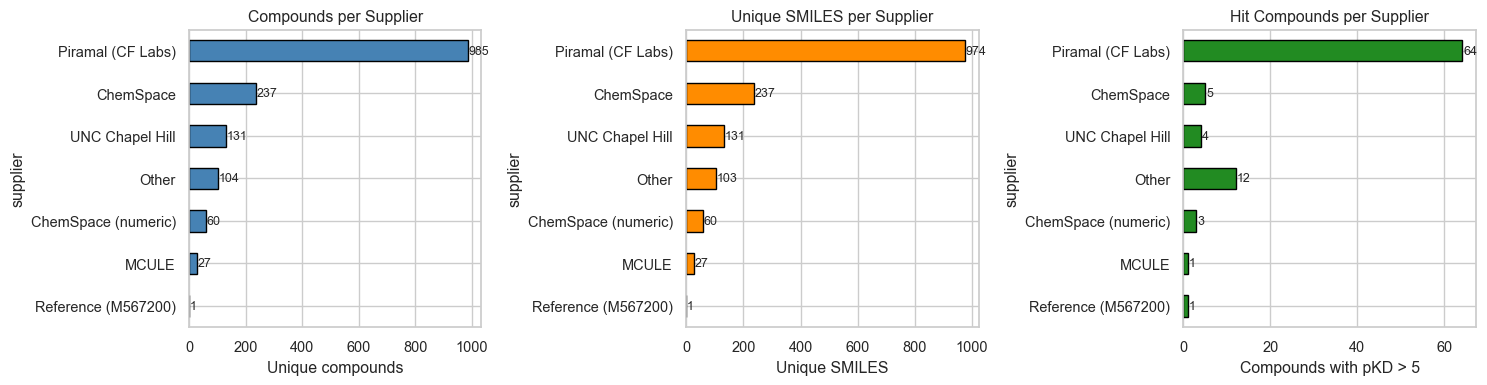

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Compounds per supplier
sc = supplier_clean.sort_values("Compounds", ascending=True)
sc["Compounds"].plot.barh(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_xlabel("Unique compounds")
axes[0].set_title("Compounds per Supplier")
for i, v in enumerate(sc["Compounds"].values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=9)

# SMILES per supplier
sc["SMILES"].plot.barh(ax=axes[1], color="darkorange", edgecolor="black")
axes[1].set_xlabel("Unique SMILES")
axes[1].set_title("Unique SMILES per Supplier")
for i, v in enumerate(sc["SMILES"].values):
    axes[1].text(v + 2, i, str(v), va="center", fontsize=9)

# Hits (pKD > 5) per supplier
sc["pKD>5 (hits)"].plot.barh(ax=axes[2], color="forestgreen", edgecolor="black")
axes[2].set_xlabel("Compounds with pKD > 5")
axes[2].set_title("Hit Compounds per Supplier")
for i, v in enumerate(sc["pKD>5 (hits)"].values):
    axes[2].text(v + 0.3, i, str(int(v)), va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 8b. Compounds per experiment batch

In [13]:
batch_summary = (
    avg.groupby("reference_date")
    .agg(
        records=("compound_id", "count"),
        unique_compounds=("compound_id", "nunique"),
        unique_smiles=("canonical_smiles", "nunique"),
        median_pKD=("pKD_mean", "median"),
        pKD_gt_5=("pKD_mean", lambda x: (x > 5).sum()),
    )
    .sort_index()
)
batch_summary.columns = ["Records", "Compounds", "SMILES", "Median pKD", "Hits (pKD>5)"]
batch_summary["Median pKD"] = batch_summary["Median pKD"].round(2)
display(Markdown("### Per-batch breakdown"))
batch_summary

### Per-batch breakdown

,Records,Compounds,SMILES,Median pKD,Hits (pKD>5)
reference_date,,,,,
20200928,124,124,123,3.20,0
20201028,87,87,87,2.97,0
20201029,127,127,127,3.05,0
20210126,131,131,130,3.33,8
20210312,85,85,85,3.31,0
20210423,124,124,124,1.91,1
20210526,104,104,104,3.39,1
20210616,125,125,125,3.14,2
20210707,117,117,117,3.18,2


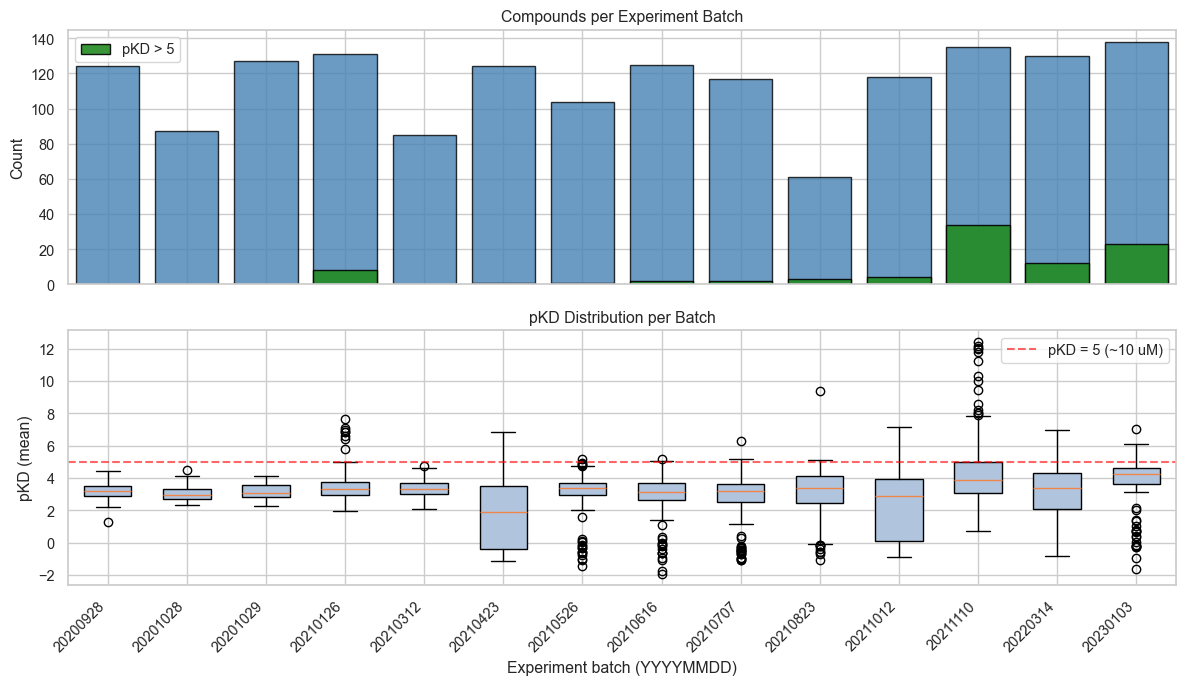

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

dates = batch_summary.index.astype(str)
x = np.arange(len(dates))

axes[0].bar(x, batch_summary["Compounds"], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].bar(x, batch_summary["Hits (pKD>5)"], color="forestgreen", edgecolor="black", alpha=0.9, label="pKD > 5")
axes[0].set_ylabel("Count")
axes[0].set_title("Compounds per Experiment Batch")
axes[0].legend()

ref_dates = sorted(avg["reference_date"].unique())
data_by_date = [avg[avg["reference_date"] == d]["pKD_mean"].values for d in ref_dates]
bp = axes[1].boxplot(data_by_date, positions=x, widths=0.6, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
axes[1].axhline(y=5.0, color="red", linestyle="--", alpha=0.6, label="pKD = 5 (~10 uM)")
axes[1].set_ylabel("pKD (mean)")
axes[1].set_title("pKD Distribution per Batch")
axes[1].set_xticks(x)
axes[1].set_xticklabels(dates, rotation=45, ha="right")
axes[1].set_xlabel("Experiment batch (YYYYMMDD)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 8c. Property distributions

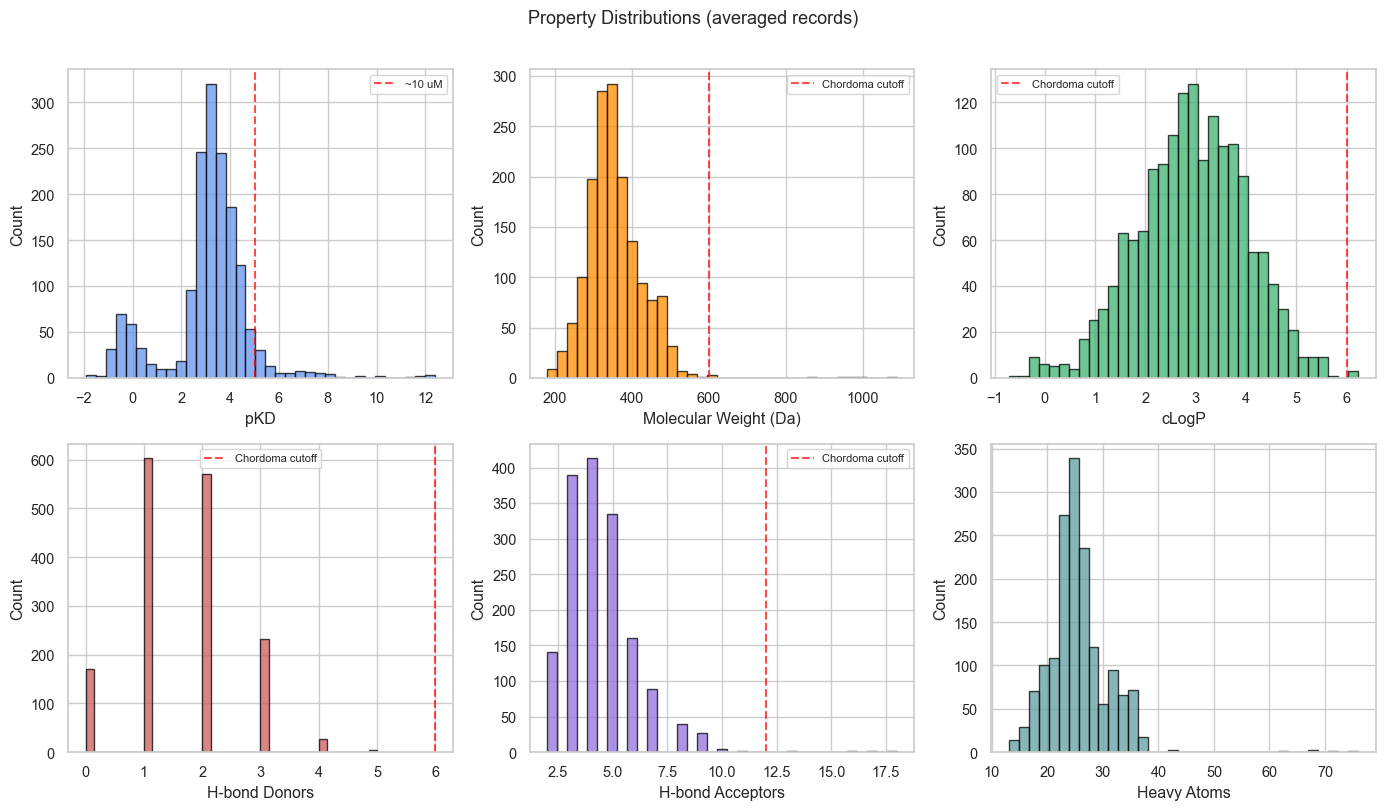

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

prop_configs = [
    ("pKD_mean", "pKD", "cornflowerblue", {"vline": 5.0, "label": "~10 uM"}),
    ("mw", "Molecular Weight (Da)", "darkorange", {"vline": 600, "label": "Chordoma cutoff"}),
    ("logp", "cLogP", "mediumseagreen", {"vline": 6, "label": "Chordoma cutoff"}),
    ("hbd", "H-bond Donors", "indianred", {"vline": 6, "label": "Chordoma cutoff"}),
    ("hba", "H-bond Acceptors", "mediumpurple", {"vline": 12, "label": "Chordoma cutoff"}),
    ("heavy_atoms", "Heavy Atoms", "cadetblue", {}),
]

for ax, (col, label, color, extras) in zip(axes.flat, prop_configs):
    data = avg[col].dropna()
    ax.hist(data, bins=35, color=color, edgecolor="black", alpha=0.75)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    if "vline" in extras:
        ax.axvline(x=extras["vline"], color="red", linestyle="--", alpha=0.7, label=extras["label"])
        ax.legend(fontsize=8)

fig.suptitle("Property Distributions (averaged records)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 8d. pKD vs. molecular properties

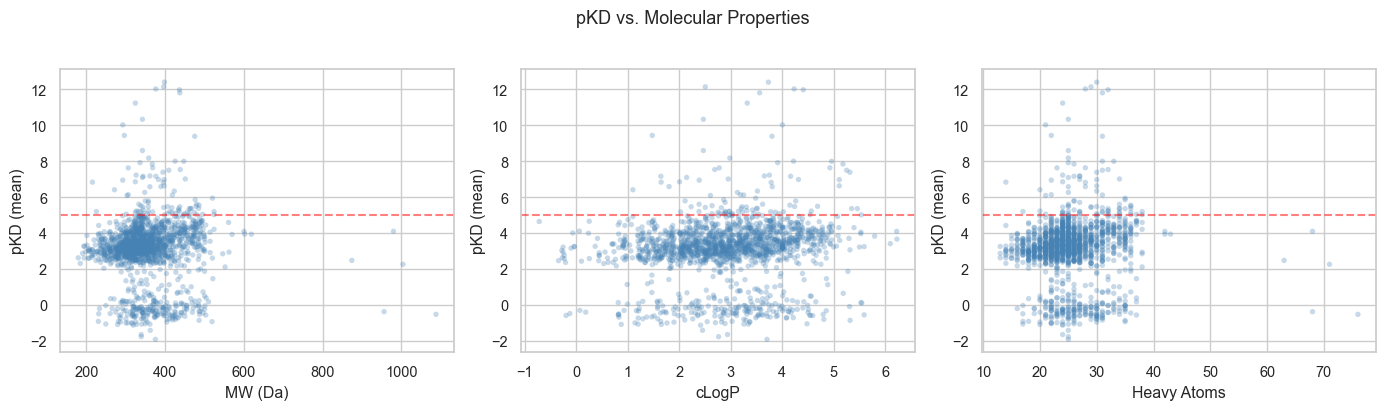

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (xcol, xlabel) in zip(axes, [("mw", "MW (Da)"), ("logp", "cLogP"), ("heavy_atoms", "Heavy Atoms")]):
    ax.scatter(avg[xcol], avg["pKD_mean"], alpha=0.3, s=15, c="steelblue", edgecolor="none")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("pKD (mean)")
    ax.axhline(y=5.0, color="red", linestyle="--", alpha=0.5)

fig.suptitle("pKD vs. Molecular Properties", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Collapse to unique compounds

For modeling we want one row per compound: the global mean pKD across all
experiment batches. The per-batch breakdown is preserved in the separate
averaged-by-date export for cross-validation fold assignment.

In [17]:
compounds = (
    avg.groupby("compound_id")
    .agg(
        canonical_smiles=("canonical_smiles", "first"),
        supplier=("supplier", "first"),
        pKD_global_mean=("pKD_mean", "mean"),
        pKD_global_std=("pKD_mean", "std"),
        n_dates=("reference_date", "nunique"),
        mw=("mw", "first"),
        logp=("logp", "first"),
        hbd=("hbd", "first"),
        hba=("hba", "first"),
        heavy_atoms=("heavy_atoms", "first"),
        num_rings=("num_rings", "first"),
        tpsa=("tpsa", "first"),
        rotatable_bonds=("rotatable_bonds", "first"),
        passes_chordoma_filters=("passes_chordoma_filters", "first"),
    )
    .reset_index()
)

display(Markdown(f"""
### Final compound table

| Metric | Value |
|--------|-------|
| Unique compounds | {len(compounds):,} |
| Unique SMILES | {compounds['canonical_smiles'].nunique():,} |
| With pKD > 5 (~<10 uM) | {(compounds['pKD_global_mean'] > 5).sum()} |
| With pKD > 6 (~<1 uM) | {(compounds['pKD_global_mean'] > 6).sum()} |
| Pass Chordoma filters | {compounds['passes_chordoma_filters'].sum()} ({100 * compounds['passes_chordoma_filters'].mean():.1f}%) |
| Tested in >1 batch | {(compounds['n_dates'] > 1).sum()} |
"""))


### Final compound table

| Metric | Value |
|--------|-------|
| Unique compounds | 1,545 |
| Unique SMILES | 1,530 |
| With pKD > 5 (~<10 uM) | 83 |
| With pKD > 6 (~<1 uM) | 40 |
| Pass Chordoma filters | 1535 (99.4%) |
| Tested in >1 batch | 50 |


In [18]:
display(Markdown("### Top 15 compounds by pKD"))
top = compounds.sort_values("pKD_global_mean", ascending=False).head(15)
top[["compound_id", "supplier", "canonical_smiles", "pKD_global_mean", "mw", "logp", "n_dates"]].round(2)

### Top 15 compounds by pKD

,compound_id,supplier,canonical_smiles,pKD_global_mean,mw,logp,n_dates
746,CF-5-293,Piramal (CF Labs),O=C(NCc1ccccc1)c1cnc(Nc2ccc(Oc3ncccn3)cc2)nc1,12.41,398.15,3.73,1
685,CF-5-206,Piramal (CF Labs),CC(C)(C)OC(=O)NCCCNC(=O)Nc1ccc(Nc2ncnc3ccccc23...,11.98,436.22,4.41,1
185,CF-2-196,Piramal (CF Labs),Cc1ccc(N2CC[C@H](Nc3ccc(Cl)c(C(=O)NCCc4cnc[nH]...,11.81,437.16,3.56,1
436,CF-3-222,Piramal (CF Labs),COc1ccc(C)cc1NC(=O)CCNc1nc2ccccc2[nH]1,11.24,324.16,3.32,1
1018,CF-9-21,Piramal (CF Labs),O=C(Nc1ccc(-c2nc(N3CCOCC3)ncc2F)cc1)C1CC1,10.34,342.15,2.47,1
1006,CF-9-09,Piramal (CF Labs),O=C1Cc2cc(-c3cc(N4CCOCC4)ncn3)ccc2N1,9.44,296.13,1.47,1
1347,MCULE-4990117039,MCULE,CC(=O)NCc1ccc(-c2nc(NC(=O)Cc3csc(NC(=O)C4CC4)n...,9.39,475.08,3.80,1
1022,CF-9-25,Piramal (CF Labs),CCOC(=O)c1cnc(N2CCOCC2)nc1-c1ccc(NC(=O)C2CC2)cc1,8.79,396.18,2.51,2
1010,CF-9-13,Piramal (CF Labs),O=C(Nc1ccc(-c2ncc(F)c(N3CCOCC3)n2)cc1)C1CC1,8.60,342.15,2.47,1
1019,CF-9-22,Piramal (CF Labs),O=C(Nc1ccc(-c2nc(N3CCOCC3)ncc2Cl)cc1)C1CC1,8.18,358.12,2.98,1


---
## 10. Export

Two CSV files are written to `data/processed/`:

1. **`tbxt_spr_averaged_by_date.csv`** — one row per (compound, experiment batch).
   Use `reference_date` as fold ID for cross-validation.
2. **`tbxt_compounds_clean.csv`** — one row per unique compound (global mean pKD).
   Primary table for modeling.

In [19]:
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

avg_out = OUT_DIR / "tbxt_spr_averaged_by_date.csv"
avg.to_csv(avg_out, index=False)
assert len(avg) == len(pd.read_csv(avg_out))
print(f"Saved {len(avg):,} rows -> {avg_out}")

cpd_out = OUT_DIR / "tbxt_compounds_clean.csv"
compounds.to_csv(cpd_out, index=False)
assert len(compounds) == len(pd.read_csv(cpd_out))
print(f"Saved {len(compounds):,} rows -> {cpd_out}")

Saved 1,606 rows -> ../data/processed/tbxt_spr_averaged_by_date.csv
Saved 1,545 rows -> ../data/processed/tbxt_compounds_clean.csv


---
## Summary

This notebook processed the merged TBXT SPR dataset through the following pipeline:

| Step | Records in | Records out | Notes |
|------|-----------|-------------|-------|
| Raw load | — | 2,143 | 14 experiment batches, Oct 2020 – Jan 2023 |
| Filter (SMILES + pKD) | 2,143 | 1,880 | Dropped 263 missing SMILES or pKD |
| Remove ambiguous IDs | 1,880 | 1,764 | 21 UNC series IDs with >1 SMILES |
| Average replicates | 1,764 | 1,606 | Mean pKD per (compound, batch) |
| Validate SMILES | 1,606 | 1,606 | 0 invalid SMILES |
| Collapse to compounds | 1,606 | 1,545 | Global mean pKD per compound |

**Output files:**
- `data/processed/tbxt_spr_averaged_by_date.csv` (1,606 rows)
- `data/processed/tbxt_compounds_clean.csv` (1,545 rows)